## Ex1. Plotting probability distributions over words

/Users/jenny/opt/anaconda3/lib/python3.9/site-packages/seaborn/_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


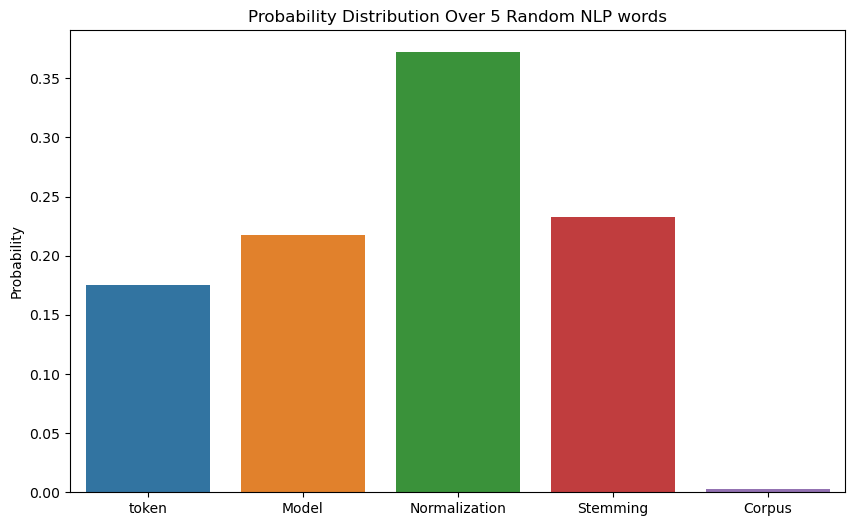

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


words = ['token', 'Model', 'Normalization', 'Stemming', 'Corpus']

# Generating synthetic probabilities for these NLP words
# Using Dirichlet distribution for simplicity
#np.random.seed(50)
p_words = np.random.dirichlet(np.ones(5), size=1)[0]
# Plotting the distribution for NLP words
plt.figure(figsize=(10, 6))
sns.barplot(x=words, y=p_words)
plt.title('Probability Distribution Over 5 Random NLP words')
plt.ylabel('Probability')
plt.xlabel('')
plt.show()


## Ex2. Generating different n-grams for a text

In [21]:
import nltk
#from nltk.tokenize import word_tokenize
from nltk import ngrams
from prettytable import PrettyTable

from nltk.tokenize import RegexpTokenizer  # uses Python’s re.findall() method to extract tokens that match the regex
mthd = RegexpTokenizer(r"\w+") # Tokenize only words, ignore punctuation


text = "Italy is famous for its cuisine."
#text = input('Please enter the text!') 

# Function to generate n-grams for a given sentence
def get_ngrams(doc, n):
    # Tokenize into words
    #tokens = word_tokenize(doc)
    tokens = mthd.tokenize(doc)
    # Generate n-grams
    ng_list = list(ngrams(tokens, n)) # nltk.ngrams() always returns tuples 
    return  ng_list

# Generate unigrams, bigrams, trigrams, and quadrigrams
list_uni=get_ngrams(text,1)   # returns tuple with 1 item
list_bi = get_ngrams(text,2)
list_tri = get_ngrams(text,3)
list_quadri = get_ngrams(text,4)

#define a function for padding (takes variable length arguments).
def column_pad(*columns):
    t_size= max([len(c) for c in columns])
    for c in columns:
        c.extend(['']*(t_size-len(c)))
column_pad(list_uni,list_bi,list_tri,list_quadri)

table = PrettyTable(['index','Unigram','Bigram', 'Trigram', 'Quadrigrams'])
table.title = "N-grams for sample text"
for j in range(len(list_uni)):
    table.add_row([j,list_uni[j],list_bi[j],list_tri[j],list_quadri[j]])
    j+=1
print(table)




+-------------------------------------------------------------------------------------------------------------+
|                                           N-grams for sample text                                           |
+-------+--------------+--------------------+---------------------------+-------------------------------------+
| index |   Unigram    |       Bigram       |          Trigram          |             Quadrigrams             |
+-------+--------------+--------------------+---------------------------+-------------------------------------+
|   0   |  ('Italy',)  |  ('Italy', 'is')   | ('Italy', 'is', 'famous') |   ('Italy', 'is', 'famous', 'for')  |
|   1   |   ('is',)    |  ('is', 'famous')  |  ('is', 'famous', 'for')  |    ('is', 'famous', 'for', 'its')   |
|   2   | ('famous',)  | ('famous', 'for')  |  ('famous', 'for', 'its') | ('famous', 'for', 'its', 'cuisine') |
|   3   |   ('for',)   |   ('for', 'its')   | ('for', 'its', 'cuisine') |                               

## Ex3. How many Pentagrams?

In [22]:
import nltk
from nltk.tokenize import word_tokenize
from nltk import ngrams
from prettytable import PrettyTable

#text="I really like large language Models."
text="The secret of business is to know something that nobody else knows."
words = word_tokenize(text)

list_penta = list(ngrams(words, 5))
#print(f" There are {len(list_penta)} Pentagrams as shown below:\n {list_penta} \n")
tab=PrettyTable(["index","Pentagrams"])
i=1
for t in list_penta:
    tab.add_row([i,t])
    i+=1
print(tab)

+-------+--------------------------------------------------+
| index |                    Pentagrams                    |
+-------+--------------------------------------------------+
|   1   |    ('The', 'secret', 'of', 'business', 'is')     |
|   2   |     ('secret', 'of', 'business', 'is', 'to')     |
|   3   |      ('of', 'business', 'is', 'to', 'know')      |
|   4   |  ('business', 'is', 'to', 'know', 'something')   |
|   5   |    ('is', 'to', 'know', 'something', 'that')     |
|   6   |  ('to', 'know', 'something', 'that', 'nobody')   |
|   7   | ('know', 'something', 'that', 'nobody', 'else')  |
|   8   | ('something', 'that', 'nobody', 'else', 'knows') |
|   9   |     ('that', 'nobody', 'else', 'knows', '.')     |
+-------+--------------------------------------------------+
